# Lecture 14: Fundamentals of Machine Learning

**F&W ECOL 458 — Environmental Data Science**

Recommended reading: Andriy Burkov, *The Hundred-Page Machine Learning Book* ([chapter links](https://github.com/tirthajyoti/Papers-Literature-ML-DL-RL-AI/blob/master/General-Machine-Learning/The%20Hundred-Page%20Machine%20Learning%20Book%20by%20Andriy%20Burkov/Links%20to%20read%20the%20chapters%20online.md))

---

### Learning objectives

By the end of this lecture you should be able to:

1. Distinguish supervised, unsupervised, and reinforcement learning and identify which category fits a given environmental problem.
2. Explain the mathematical setup of linear regression and logistic regression.
3. Walk through the standard `scikit-learn` workflow: load → preprocess → split → train → evaluate.
4. Interpret a confusion matrix and compute accuracy, precision, recall, and F1.
5. Recognize overfitting vs. underfitting and explain why a train/test split is essential.


## 1. What is Machine Learning?

Machine learning (ML) is the process of building algorithms that learn patterns from data rather than being explicitly programmed with rules.

The general workflow is:

1. **Gather a dataset** of examples that represent some phenomenon of interest.
2. **Choose and train a statistical model** that captures the structure in the data.
3. **Use the trained model** to make predictions on new, unseen data.

### Why does ML matter for environmental science?

Environmental datasets are often high-dimensional (many spectral bands, many species, many climate variables) and exhibit complex, nonlinear relationships. ML provides tools to:

- classify land-cover types from satellite imagery,
- predict wildfire risk from weather and fuel-moisture data,
- forecast species distributions under climate change,
- gap-fill eddy-covariance flux measurements.


### Types of Learning

![Types of Machine Learning](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*6iDmbHflsN6NULBLpVHA6A.png)

There are three major paradigms of machine learning:

| Paradigm | Input data | Goal | Environmental example |
|---|---|---|---|
| **Supervised** | Labeled examples $(\mathbf{x}_i, y_i)$ | Predict label $y$ for new $\mathbf{x}$ | Classify pixels as forest / cropland / water |
| **Unsupervised** | Unlabeled examples $\mathbf{x}_i$ | Discover structure or clusters | Group watersheds by similar hydrological behavior |
| **Reinforcement** | States, actions, rewards | Learn a policy that maximizes cumulative reward | Optimize prescribed-burn scheduling |

We will focus on **supervised learning** in this lecture because it is the foundation for most predictive modeling tasks in environmental data science.


### Supervised Learning

In supervised learning we start with a **labeled dataset** of $N$ examples:

$$
\{(\mathbf{x}_i,\; y_i)\}_{i=1}^{N}
$$

- $\mathbf{x}_i \in \mathbb{R}^M$ is a **feature vector** with $M$ attributes describing the $i$-th observation.
- $y_i$ is the **label** — either a discrete class (classification) or a continuous value (regression).

#### Ecological example

Suppose we build a dataset describing forest plots:

| Feature | Description |
|---|---|
| Mean annual temperature (°C) | Climate |
| Annual precipitation (mm) | Climate |
| Elevation (m) | Topography |
| NDVI (unitless) | Remote sensing |
| Canopy height (m) | Structure |

And the label $y_i$ could be:

- **Classification**: dominant forest type (deciduous, coniferous, mixed)
- **Regression**: aboveground biomass (Mg C ha⁻¹)

> **Discussion prompt:** What are $\mathbf{x}_i$ and $y_i$ if we want to predict a species' presence/absence from environmental covariates?

The goal of a supervised learning algorithm is to produce a model $f$ such that $f(\mathbf{x}) \approx y$ for *new* observations not seen during training.


### Unsupervised Learning

In unsupervised learning the dataset contains only feature vectors — **no labels**:

$$
\{\mathbf{x}_i\}_{i=1}^{N}
$$

The goal is to discover hidden structure such as clusters, latent dimensions, or density patterns. Common applications in environmental science:

- **Clustering** remote-sensing pixels into spectrally similar groups (unsupervised classification).
- **Dimensionality reduction** (PCA, as you saw in FWE 711) to summarize multivariate community data.
- **Anomaly detection** to flag sensor malfunctions in flux-tower data.


### Reinforcement Learning (brief overview)

In reinforcement learning (RL), an **agent** interacts with an **environment** by taking actions and receiving rewards. The goal is to learn a **policy** — a mapping from states to actions — that maximizes long-term cumulative reward.

RL is less common in day-to-day environmental data science but appears in areas such as adaptive natural-resource management, robotic environmental sampling, and real-time irrigation control. We will not implement RL in this course, but you should be aware of the paradigm.


## 2. Commonly Used ML Algorithms

Here is a (non-exhaustive) list of algorithms you will encounter, organized by task:

| Classification | Regression | Clustering |
|---|---|---|
| Logistic regression | Linear regression | K-Means |
| Support Vector Machine (SVM) | Ridge / Lasso regression | Hierarchical clustering |
| Decision tree / Random forest | Decision tree / Random forest | DBSCAN |
| *k*-Nearest Neighbors (KNN) | Gradient boosting | Gaussian mixture models |
| Artificial neural networks | Artificial neural networks | — |

In this lecture we will walk through **linear regression** and **logistic regression** in detail. Later lectures will cover tree-based methods and other approaches.


### 2.1 Linear Regression

Linear regression predicts a continuous response $y$ as a linear function of the feature vector $\mathbf{x}$:

$$
\hat{y} = \mathbf{w}^\top \mathbf{x} + b
$$

where $\mathbf{w}$ is a vector of **weights** (one per feature) and $b$ is a **bias** (intercept) term.

#### Loss functions

To train the model we need a measure of how far the predictions $\hat{y}_i$ are from the true values $y_i$. Two common choices:

**Mean Absolute Error (MAE):**

$$
\text{MAE} = \frac{1}{N}\sum_{i=1}^{N} |\hat{y}_i - y_i|
$$

**Mean Squared Error (MSE):**

$$
\text{MSE} = \frac{1}{N}\sum_{i=1}^{N} (\hat{y}_i - y_i)^2
$$

MSE is more commonly used because it is differentiable everywhere, which makes optimization via gradient descent straightforward. Squaring also penalizes large errors more heavily.

Training a linear regression model means finding $\mathbf{w}$ and $b$ that **minimize** the chosen loss function (also called the **cost function** $J(\mathbf{w}, b)$).

> **Note on the 1/2 convention:** Some textbooks write the MSE with a factor of $\frac{1}{2N}$ instead of $\frac{1}{N}$. The $\frac{1}{2}$ is a convenience that cancels the exponent when you take the derivative during gradient descent — the optimal $\mathbf{w}$ is the same either way.


Slope (w):                998.6
Intercept (b):            152.0
Mean squared error (MSE): 4061.8
R² score:                 0.233


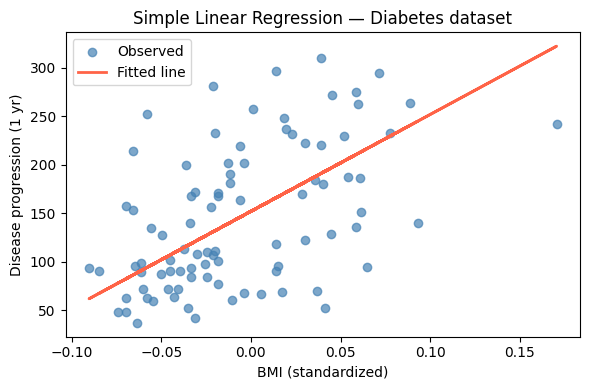

In [ ]:
# === Linear Regression Example: Predicting diabetes progression ===
# Adapted from scikit-learn documentation (BSD 3-clause license)

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the diabetes dataset (10 baseline variables, target = disease progression)
X, y = datasets.load_diabetes(return_X_y=True)

# For visualization, use only one feature: Body Mass Index (column 2)
X_bmi = X[:, np.newaxis, 2]

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_bmi, y, test_size=0.20, random_state=42
)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# ── Evaluate ──
print(f"Slope (w):                {model.coef_[0]:.1f}")
print(f"Intercept (b):            {model.intercept_:.1f}")
print(f"Mean squared error (MSE): {mean_squared_error(y_test, y_pred):.1f}")
print(f"R² score:                 {r2_score(y_test, y_pred):.3f}")

# ── Plot ──
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_test, y_test, color="steelblue", alpha=0.7, label="Observed")
ax.plot(X_test, y_pred, color="tomato", linewidth=2, label="Fitted line")
ax.set_xlabel("BMI (standardized)")
ax.set_ylabel("Disease progression (1 yr)")
ax.set_title("Simple Linear Regression — Diabetes dataset")
ax.legend()
plt.tight_layout()
plt.show()


### 2.2 Logistic Regression

Despite the name, **logistic regression is a classification algorithm**, not a regression. The name comes from the fact that it extends linear regression with the **logistic (sigmoid) function**.

#### Why not just use a linear function for classification?

If our labels are binary ($y \in \{0, 1\}$), a plain linear model $\hat{y} = \mathbf{w}^\top\mathbf{x} + b$ can produce any real number — it is not naturally bounded between 0 and 1. We need a way to map the linear output to a probability.

#### The sigmoid function

The **standard logistic (sigmoid) function** squashes any real-valued input into the range $(0, 1)$:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Applying this to the linear model gives the logistic regression model:

$$
P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}
$$

We interpret the output as the **probability** that the observation belongs to the positive class. A common decision rule is:

$$
\hat{y} = \begin{cases} 1 & \text{if } P(y=1 \mid \mathbf{x}) \geq 0.5 \\ 0 & \text{otherwise} \end{cases}
$$

The threshold 0.5 can be adjusted depending on the cost of false positives vs. false negatives — for example, in rare-species detection you might lower the threshold to avoid missing true presences.

#### Comparing linear and logistic regression

| | Linear regression | Logistic regression |
|---|---|---|
| **Task** | Regression (continuous $y$) | Classification (discrete $y$) |
| **Model output** | Unbounded real value | Probability in $(0, 1)$ |
| **Loss function** | Mean squared error | Cross-entropy (log-loss) |
| **Example** | Predict stream discharge from rainfall | Classify wetland vs. upland from spectral data |


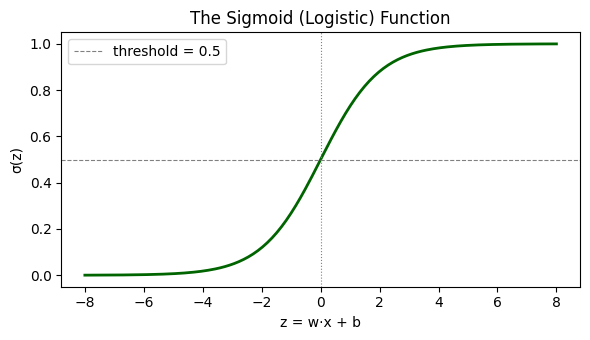

In [ ]:
# === Visualize the sigmoid function ===
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-8, 8, 200)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(z, sigma, color="darkgreen", linewidth=2)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="threshold = 0.5")
ax.axvline(0, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("z = w·x + b")
ax.set_ylabel("σ(z)")
ax.set_title("The Sigmoid (Logistic) Function")
ax.legend()
plt.tight_layout()
plt.show()


## 3. The `scikit-learn` Workflow

[`scikit-learn`](https://scikit-learn.org/) (imported as `sklearn`) provides a consistent API for building ML models in Python. The typical workflow is:

```
Load data → Preprocess → Train/test split → Instantiate model → Fit → Predict → Evaluate
```

Key steps in more detail:

1. **Import** the relevant modules (`sklearn.model_selection`, `sklearn.preprocessing`, your chosen estimator, and evaluation metrics).
2. **Load and explore** the data — check for missing values, class balance, and feature distributions.
3. **Preprocess** — handle missing data, encode categorical variables, and scale features if needed (many algorithms are sensitive to feature magnitudes).
4. **Split** into training and test sets with `train_test_split`. The test set must be held out and **never** used during model training or tuning.
5. **Instantiate and fit** the model (`.fit(X_train, y_train)`).
6. **Predict** on the test set (`.predict(X_test)`).
7. **Evaluate** with appropriate metrics (accuracy, MSE, $R^2$, etc.).
8. **Iterate** — try different preprocessing, models, or hyperparameters.

Let's apply this workflow to two complete examples.


### Example 1: Predicting diabetes progression (regression)

We already saw this above. The key code pattern is:

```python
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²: ", r2_score(y_test, y_pred))
```


### Example 2: Classifying iris species (classification)

The classic Iris dataset contains four petal/sepal measurements for 150 flowers from three species. This is a multi-class classification problem.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# ── Load data ──
iris = load_iris()
X, y = iris.data, iris.target
print(f"Features: {iris.feature_names}")
print(f"Classes:  {iris.target_names}")
print(f"Dataset shape: {X.shape}  (N={X.shape[0]} samples, M={X.shape[1]} features)\n")

# ── Train/test split (75 % train, 25 % test) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# ── Instantiate and train ──
# max_iter=200 ensures convergence for this dataset
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train, y_train)

# ── Predict and evaluate ──
y_pred = logreg.predict(X_test)

accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Overall accuracy: {accuracy:.2%}\n")
print("Classification report:")
print(metrics.classification_report(y_test, y_pred, target_names=iris.target_names))


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:  ['setosa' 'versicolor' 'virginica']
Dataset shape: (150, 4)  (N=150 samples, M=4 features)

Overall accuracy: 97.37%

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.94      0.97        16
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



## 4. Evaluating Classification Models: The Confusion Matrix

A **confusion matrix** is a table that summarizes prediction results by comparing predicted labels to true labels. For a binary classifier:

|  | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actually Positive** | True Positive (TP) | False Negative (FN) — *Type II error* |
| **Actually Negative** | False Positive (FP) — *Type I error* | True Negative (TN) |

From these counts we derive several important metrics:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
\text{Precision} = \frac{TP}{TP + FP} \quad\text{(of everything predicted positive, how many truly are?)}
$$

$$
\text{Recall (Sensitivity)} = \frac{TP}{TP + FN} \quad\text{(of everything actually positive, how many did we find?)}
$$

$$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

#### Why not just use accuracy?

In environmental applications, **classes are often highly imbalanced**. For example, if 95 % of satellite pixels are "not burned" and 5 % are "burned," a model that always predicts "not burned" has 95 % accuracy — but 0 % recall for the class we care about! Precision, recall, and F1 give a more honest picture.

For multi-class problems the confusion matrix extends to an $N_\text{classes} \times N_\text{classes}$ grid. The diagonal entries are correct predictions; off-diagonal entries reveal which classes are being confused.


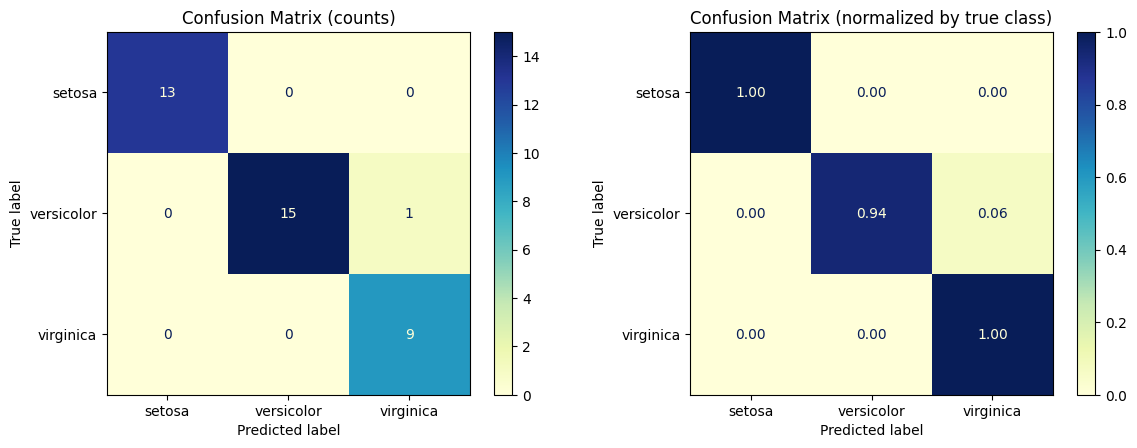

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# ── Visualize the confusion matrix from the Iris classifier ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Raw counts
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=iris.target_names,
    cmap="YlGnBu",
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix (counts)")

# Normalized (row-wise → recall per class)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=iris.target_names,
    normalize="true",
    cmap="YlGnBu",
    ax=axes[1],
    values_format=".2f"
)
axes[1].set_title("Confusion Matrix (normalized by true class)")

plt.tight_layout()
plt.show()


## 5. Overfitting, Underfitting, and the Bias–Variance Tradeoff

One of the most important concepts in ML is **generalization** — how well a model performs on data it has *never seen*.

### Underfitting (high bias)

The model is too simple to capture the true pattern. Training error *and* test error are both high.  
*Example:* fitting a straight line to a clearly nonlinear relationship between elevation and species richness.

### Overfitting (high variance)

The model is too complex and memorizes noise in the training data. Training error is very low, but test error is high.  
*Example:* a decision tree with no depth limit that perfectly classifies every training pixel but fails on new satellite imagery.

### The bias–variance tradeoff

| | Low variance | High variance |
|---|---|---|
| **Low bias** | Ideal (rarely achieved) | Overfitting |
| **High bias** | Underfitting | Bad all around |

In practice, we tune model complexity (e.g., regularization strength, tree depth) to find the sweet spot that minimizes *test* error.

### Practical safeguards

- **Train/test split:** Always hold out a portion of data (e.g., 20–30 %) that the model never sees during training.
- **Cross-validation:** Repeatedly split the data into *k* folds, train on $k-1$, test on 1, and average results. This gives a more robust estimate of generalization performance.
- **Regularization:** Add a penalty for large weights (L1 / L2 regularization) to discourage overly complex models.


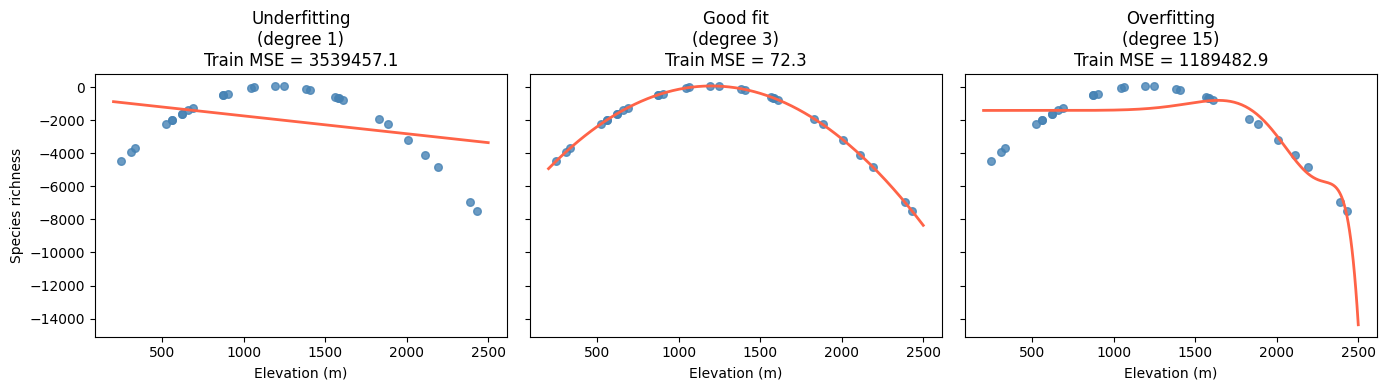

In [ ]:
# === Overfitting demonstration: polynomial regression ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Generate synthetic "ecological" data: species richness vs. elevation
np.random.seed(42)
n = 30
elevation = np.sort(np.random.uniform(200, 2500, n))
# True relationship is a hump-shaped curve (common in ecology)
richness_true = -0.005 * (elevation - 1200)**2 + 80
richness = richness_true + np.random.normal(0, 10, n)

X = elevation.reshape(-1, 1)
elev_fine = np.linspace(200, 2500, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
degrees = [1, 3, 15]
labels = ["Underfitting\n(degree 1)", "Good fit\n(degree 3)", "Overfitting\n(degree 15)"]

for ax, deg, lab in zip(axes, degrees, labels):
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(X, richness)
    y_fit = pipe.predict(elev_fine)
    mse = mean_squared_error(richness, pipe.predict(X))

    ax.scatter(elevation, richness, color="steelblue", s=30, alpha=0.8)
    ax.plot(elev_fine, y_fit, color="tomato", linewidth=2)
    ax.set_title(f"{lab}\nTrain MSE = {mse:.1f}")
    ax.set_xlabel("Elevation (m)")

axes[0].set_ylabel("Species richness")
plt.tight_layout()
plt.show()


### Cross-validation in practice

`scikit-learn` makes *k*-fold cross-validation simple:


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

logreg = LogisticRegression(max_iter=200)

# 5-fold cross-validation
scores = cross_val_score(logreg, X, y, cv=5, scoring="accuracy")
print(f"Accuracy per fold: {scores}")
print(f"Mean accuracy:     {scores.mean():.3f} ± {scores.std():.3f}")


Accuracy per fold: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Mean accuracy:     0.973 ± 0.025


## 6. Summary

| Concept | Key takeaway |
|---|---|
| Supervised learning | Learn $f(\mathbf{x}) \approx y$ from labeled examples |
| Linear regression | Predict continuous $y$; minimize MSE |
| Logistic regression | Classify discrete $y$; uses sigmoid to output probabilities |
| Confusion matrix | Reveals *which* errors a classifier makes; use precision/recall for imbalanced data |
| Overfitting vs. underfitting | Model complexity must be tuned; use train/test split and cross-validation |
| `scikit-learn` workflow | Load → preprocess → split → fit → predict → evaluate → iterate |

### Next lecture

We will apply these ideas to **environmental datasets** — land-cover classification from Landsat imagery and species-distribution modeling — and introduce **decision trees** and **random forests**.
